# ChemAI: Predict the Cure

Ссылка на соревнование: https://www.kaggle.com/competitions/chem-ai-predict-the-cure/overview

### Описание задачи:
Разработка новых лекарственных препаратов - сложный и длительный процесс, включающий синтез соединений и их биологическое тестирование. Современные методы машинного обучения позволяют ускорить этот процесс, предсказывая эффективность химических соединений до проведения лабораторных экспериментов.

В этом соревновании предстоит выступить в роли ML инженеров в команде фармацевтической разработки.

Химики предоставили данные о свойствах молекул и их биологической активности против вируса гриппа. Задача - построить модели, способные предсказывать эффективность новых соединений.

Для каждого химического соединения необходимо предсказать три показателя:  
IC50 (mM) - концентрация, при которой вещество подавляет 50% активности вируса.  
CC50 (mM) - концентрация, при которой вещество токсично для 50% клеток.  
SI (Selectivity Index) - индекс селективности.

По условию задания допускается обучать одну multi-target модель или отдельные модели для каждой переменной.

### Описание датасета:
В соревновании используются данные о 1000 химических соединениях, описанных с помощью числовых молекулярных дескрипторов.

Данные разделены на:  
train.csv - 751 объект с известными значениями целевых переменных.  
test.csv - 250 объектов, для которых необходимо сделать предсказания.

В обучающей выборке представлены три целевые переменные:  
IC50 - концентрация вещества, при которой подавляется 50% биологической активности.  
CC50 - концентрация, при которой наблюдается токсичность для 50% клеток.  
SI (Selectivity Index) - индекс селективности, характеризующий эффективность соединения.

SI связан с IC50 и CC50, однако в рамках соревнования его необходимо предсказывать как отдельную переменную.

### Описание признаков:
Каждое химическое соединение описывается 214 числовыми признаками, отражающими его физико-химические, структурные и электронные свойства.

Признаки можно условно разделить на несколько групп:

1. Общие молекулярные свойства (MolWt, ExactMolWt, HeavyAtomMolWt, NumValenceElectrons, NumRadicalElectrons, MolLogP, MolMR, TPSA, LabuteASA,...).

2. Электронные и зарядовые характеристики (MaxPartialCharge, MinPartialCharge, MaxAbsPartialCharge, MinAbsPartialCharge, PEOE_VSA* - дескрипторы, связанные с распределением электронной плотности)

3. Топологические и структурные дескрипторы (Chi*, Kappa*, BalabanJ, BertzCT, HallKierAlpha, Ipc, FractionCSP3, RingCount, ...).

4. Поверхностные дескрипторы (VSA) (SMR_VSA*, SlogP_VSA*, EState_VSA*, VSA_EState*, ...).

5. Функциональные группы (fr_*) (Бинарные признаки, отражающие наличие различных химических групп: fr_alkyl_halide, fr_ester, fr_ether, fr_ketone, fr_benzene, fr_pyridine, fr_imidazole, fr_amide, fr_amine, fr_nitro, fr_halogen и многие другие).

6. Специфические дескрипторы (EState индексы (MaxEStateIndex, MinEStateIndex и др.), BCUT2D_* - спектральные дескрипторы, FpDensityMorgan* - плотности молекулярных отпечатков).

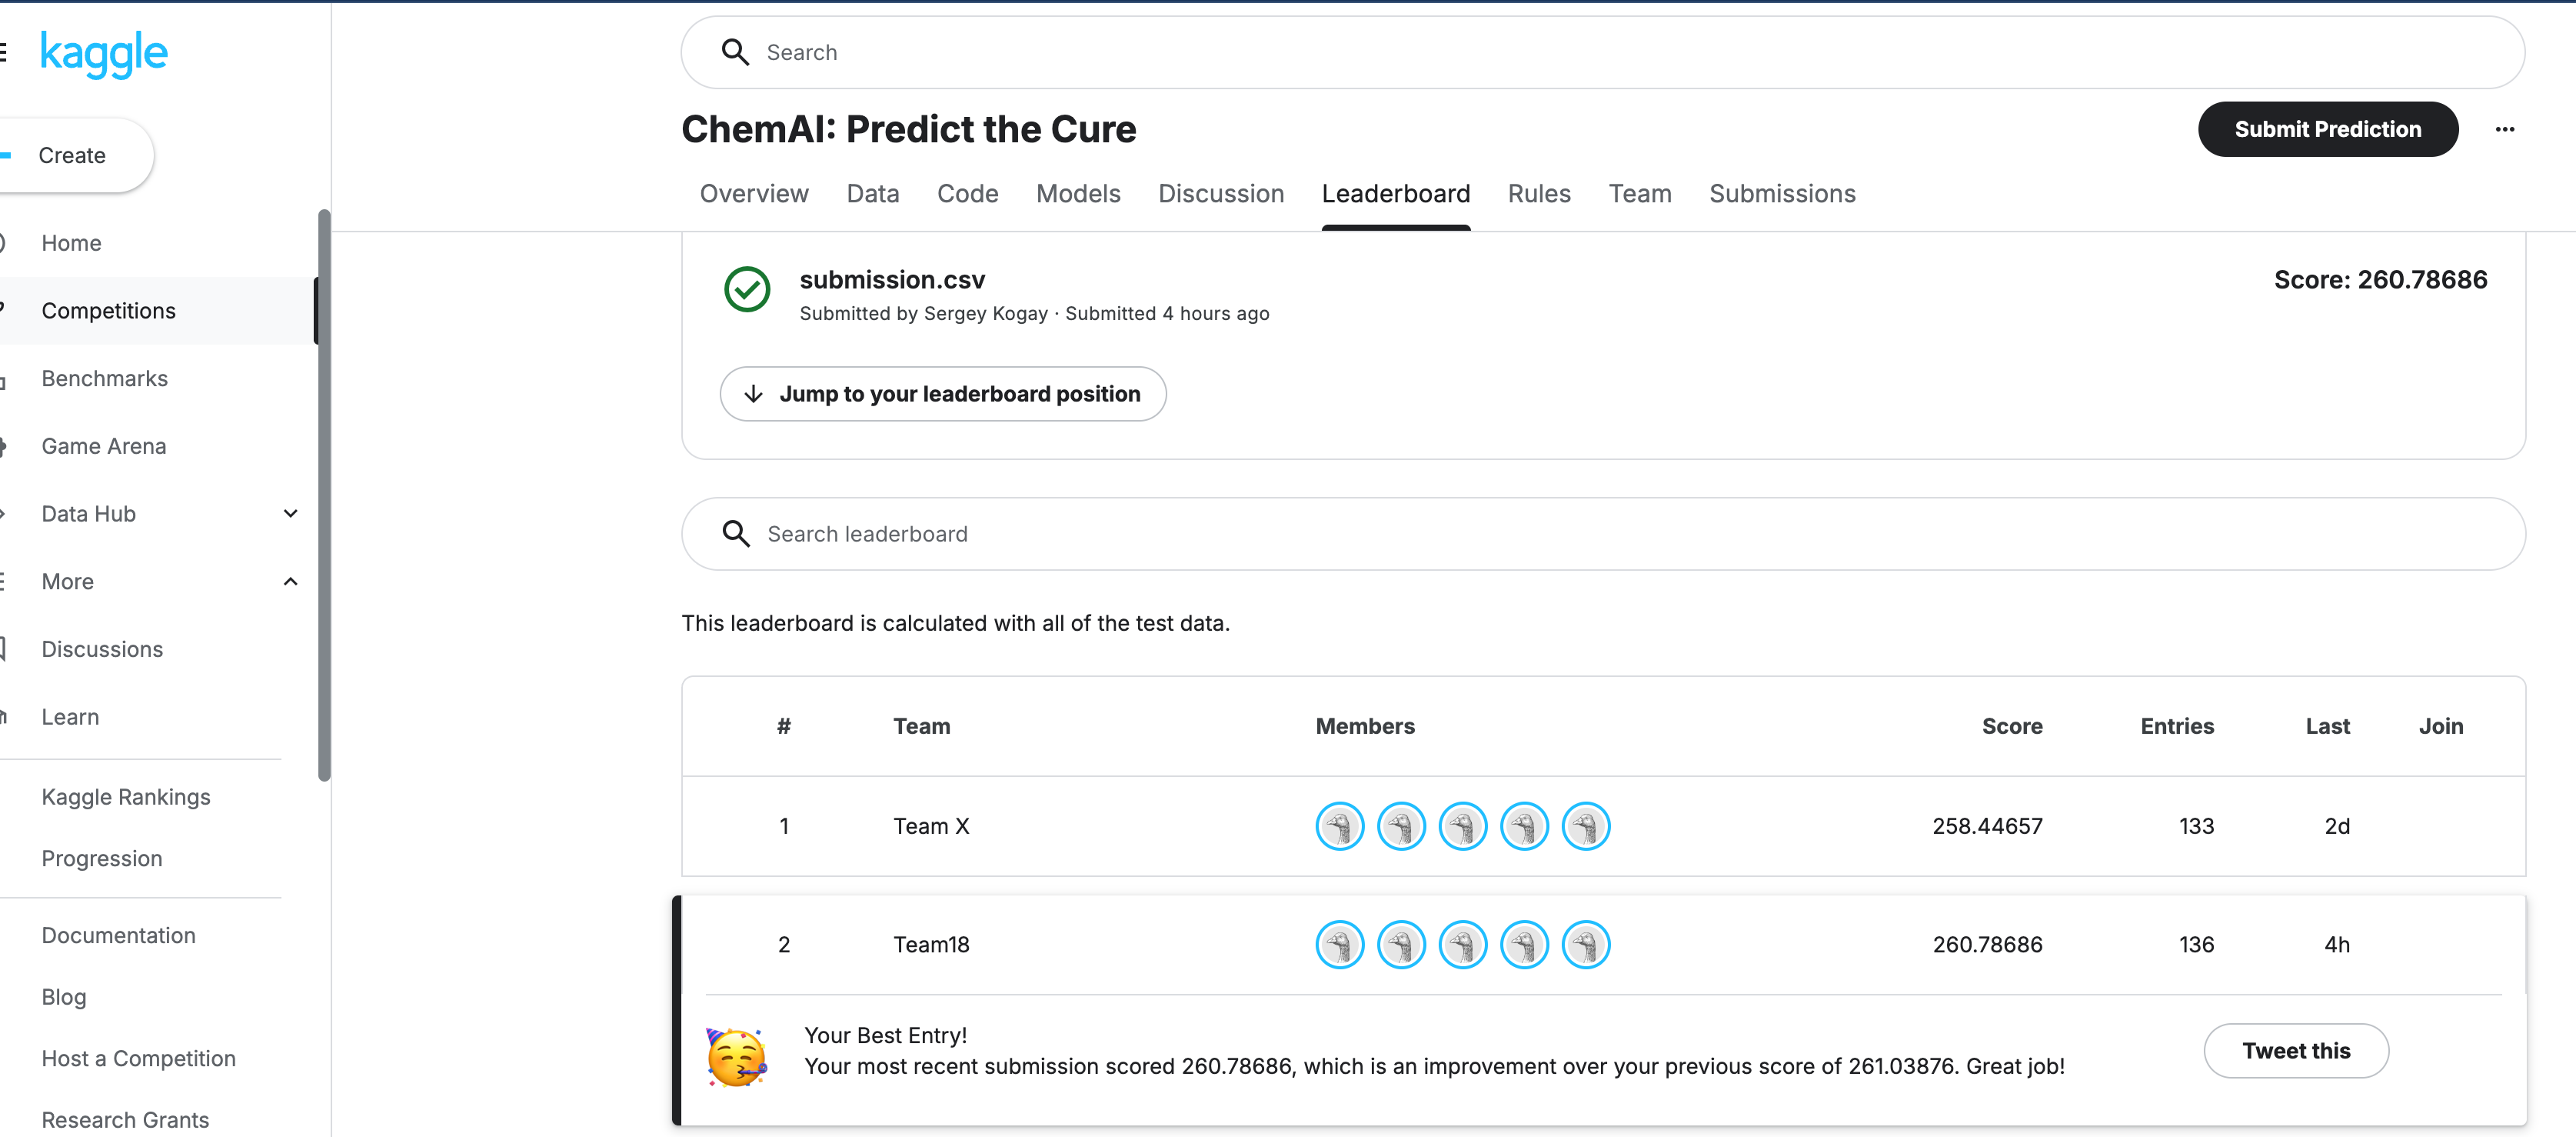

In [27]:
from IPython.display import Image
Image(filename='score.png')

In [14]:
# Импортируем библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

In [15]:
# Загружаем данные
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

In [16]:
# Первичный обзор числовых признаков:
# count, mean, std, min/max и квартили помогают быстро увидеть масштаб признаков,
# возможные выбросы и признаки с подозрительно малой вариативностью.
display(train.describe().T)

,count,mean,std,min,25%,50%,75%,max
index,751.0,3.750000e+02,2.169393e+02,0.000000e+00,187.500000,375.000000,5.625000e+02,7.500000e+02
"IC50, mM",751.0,2.045440e+02,3.703679e+02,3.516694e-03,13.222351,44.069306,2.067874e+02,4.095189e+03
"CC50, mM",751.0,5.774261e+02,6.415152e+02,7.008079e-01,99.998894,376.580899,8.775088e+02,4.538976e+03
SI,751.0,8.915331e+01,7.888822e+02,1.148927e-02,1.500000,4.000000,1.737246e+01,1.562060e+04
MaxAbsEStateIndex,751.0,1.086007e+01,3.347314e+00,2.321942e+00,8.921032,12.197500,1.321424e+01,1.593346e+01
MaxEStateIndex,751.0,1.086007e+01,3.347314e+00,2.321942e+00,8.921032,12.197500,1.321424e+01,1.593346e+01
MinAbsEStateIndex,751.0,1.800643e-01,1.691630e-01,3.921013e-05,0.048473,0.121372,2.909895e-01,1.374614e+00
MinEStateIndex,751.0,-9.718898e-01,1.594491e+00,-6.992796e+00,-1.333831,-0.419485,7.248837e-02,1.374614e+00
qed,751.0,5.779377e-01,2.141903e-01,5.956678e-02,0.442842,0.636477,7.424828e-01,9.472648e-01
SPS,751.0,2.958801e+01,1.271320e+01,9.545455e+00,18.306020,29.281250,3.887500e+01,6.027273e+01


### Первичный EDA

На первом этапе был выполнен базовый обзор тренировочного датасета с помощью `describe()`.

Цели анализа:

- проверить размерность данных и убедиться, что признаки представлены числовыми значениями;
- оценить масштабы признаков, так как молекулярные дескрипторы могут иметь сильно разные диапазоны;
- заметить признаки с нулевой или очень низкой вариативностью;
- увидеть потенциальные выбросы по большим значениям `max` относительно медианы и квартилей;
- предварительно оценить распределение целевых переменных.

По результатам первичного анализа дальнейшая обработка была направлена на удаление неинформативных признаков: константных, маловариативных и сильно скоррелированных дескрипторов.

In [17]:
# Удаляем константные признаки.
# Такие признаки имеют одно и то же значение для всех объектов train,
# поэтому не помогают модели различать соединения и могут только добавлять шум.
def remove_constant_features(
    train,
    test,
    target_columns,
    id_columns=("index",),
    verbose=True
):
    """
    Удаляет константные признаки из train и test.

    Логика:
    - константные признаки ищутся только по train;
    - target_columns и id_columns не участвуют в отборе;
    - из test удаляются те же признаки, что и из train.
    """

    train_filtered = train.copy()
    test_filtered = test.copy()

    protected_columns = list(target_columns) + list(id_columns)

    train_feature_columns = [
        col for col in train_filtered.columns
        if col not in protected_columns
    ]

    constant_features = [
        col for col in train_feature_columns
        if train_filtered[col].nunique(dropna=False) <= 1
    ]

    train_shape_before = train_filtered.shape
    test_shape_before = test_filtered.shape

    train_filtered = train_filtered.drop(
        columns=constant_features,
        errors="ignore"
    )

    test_filtered = test_filtered.drop(
        columns=constant_features,
        errors="ignore"
    )

    if verbose:
        print("Constant feature filtering")
        print("-" * 40)

        print("Dropped features:", len(constant_features))
        print(constant_features)

        print("\nTrain before:", train_shape_before)
        print("Train after: ", train_filtered.shape)

        print("\nTest before:", test_shape_before)
        print("Test after: ", test_filtered.shape)

    return train_filtered, test_filtered, constant_features

target_columns = ["IC50, mM", "CC50, mM", "SI"]

train, test, constant_features = remove_constant_features(
    train=train,
    test=test,
    target_columns=target_columns,
    id_columns=("index",),
    verbose=True
)

Constant feature filtering
----------------------------------------
Dropped features: 18
['NumRadicalElectrons', 'SMR_VSA8', 'SlogP_VSA9', 'fr_N_O', 'fr_SH', 'fr_azide', 'fr_barbitur', 'fr_benzodiazepine', 'fr_diazo', 'fr_dihydropyridine', 'fr_isocyan', 'fr_isothiocyan', 'fr_lactam', 'fr_nitroso', 'fr_phos_acid', 'fr_phos_ester', 'fr_prisulfonamd', 'fr_thiocyan']

Train before: (751, 214)
Train after:  (751, 196)

Test before: (250, 211)
Test after:  (250, 193)


In [18]:
# Удаляем маловариативные признаки только среди НЕ fr_* признаков.
# Функциональные группы fr_* оставляем, потому что даже редкие фрагменты
# могут быть химически значимыми и улучшали качество на валидации/сабмите.
def remove_low_variance_non_fr_features(
    train,
    test,
    target_columns,
    id_columns,
    fr_prefix,
    variance_threshold,
):
    """
    Удаляет низковариативные признаки только среди НЕ fr_* признаков.

    Логика:
    - отбор признаков делается только по train;
    - fr_* признаки не удаляются;
    - target_columns и id_columns сохраняются;
    - test фильтруется тем же набором признаков, что и train.
    """

    train_filtered = train.copy()
    test_filtered = test.copy()

    protected_columns = list(target_columns) + list(id_columns)

    feature_columns = [
        c for c in train_filtered.columns
        if c not in protected_columns
    ]

    fr_features = [
        c for c in feature_columns
        if c.startswith(fr_prefix)
    ]

    other_features = [
        c for c in feature_columns
        if not c.startswith(fr_prefix)
    ]

    train_shape_before = train_filtered.shape
    test_shape_before = test_filtered.shape

    selector = VarianceThreshold(threshold=variance_threshold)

    selector.fit(train_filtered[other_features])

    selected_other_features = [
        feature
        for feature, keep in zip(other_features, selector.get_support())
        if keep
    ]

    removed_features = [
        feature
        for feature, keep in zip(other_features, selector.get_support())
        if not keep
    ]

    final_features = selected_other_features + fr_features

    train_columns_to_keep = (
        [c for c in id_columns if c in train_filtered.columns]
        + final_features
        + [c for c in target_columns if c in train_filtered.columns]
    )

    test_columns_to_keep = (
        [c for c in id_columns if c in test_filtered.columns]
        + final_features
    )

    train_filtered = train_filtered[train_columns_to_keep].copy()
    test_filtered = test_filtered[test_columns_to_keep].copy()


    print("Low-variance filtering for non-fr_* features")
    print("-" * 50)
    print("Variance threshold:", variance_threshold)

    print("\nTrain before:", train_shape_before)
    print("Train after: ", train_filtered.shape)

    print("\nTest before:", test_shape_before)
    print("Test after: ", test_filtered.shape)

    print("\nNon-fr_* features checked:", len(other_features))
    print("fr_* features kept without filtering:", len(fr_features))

    print("\nDropped features:", len(removed_features))
    print(removed_features)

    return train_filtered, test_filtered, removed_features, final_features

target_columns = ["IC50, mM", "CC50, mM", "SI"]

train, test, low_variance_features, final_features = remove_low_variance_non_fr_features(
    train=train,
    test=test,
    target_columns=target_columns,
    id_columns=("index",),
    fr_prefix="fr_",
    variance_threshold=0.01,
)

Low-variance filtering for non-fr_* features
--------------------------------------------------
Variance threshold: 0.01

Train before: (751, 196)
Train after:  (751, 194)

Test before: (250, 193)
Test after:  (250, 191)

Non-fr_* features checked: 122
fr_* features kept without filtering: 70

Dropped features: 2
['MinPartialCharge', 'MaxAbsPartialCharge']


In [19]:
# Удаляем сильно скоррелированные признаки.
# Для молекулярных дескрипторов это особенно актуально: многие признаки
# описывают близкие физико-химические свойства и частично дублируют друг друга.
def remove_highly_correlated_features(
    train,
    test,
    target_columns,
    id_columns,
    correlation_threshold,
):
    """
    Удаляет сильно скоррелированные признаки.

    Логика:
    - признаки анализируются только по train;
    - target_columns и id_columns не участвуют в отборе;
    - если два признака имеют |corr| >= correlation_threshold, удаляется один из них;
    - из test удаляются те же признаки, что и из train.
    """

    train_filtered = train.copy()
    test_filtered = test.copy()

    protected_columns = list(target_columns) + list(id_columns)

    feature_columns = [
        col for col in train_filtered.columns
        if col not in protected_columns
    ]

    train_shape_before = train_filtered.shape
    test_shape_before = test_filtered.shape

    X = train_filtered[feature_columns].copy()

    corr_matrix = X.corr(method="pearson").abs()

    upper_triangle = corr_matrix.where(
        np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    )

    features_to_drop = [
        column
        for column in upper_triangle.columns
        if any(upper_triangle[column] >= correlation_threshold)
    ]

    train_filtered = train_filtered.drop(
        columns=features_to_drop,
        errors="ignore"
    )

    test_filtered = test_filtered.drop(
        columns=features_to_drop,
        errors="ignore"
    )

    final_features = [
        col for col in feature_columns
        if col not in features_to_drop
    ]

    print("Highly correlated feature filtering")
    print("-" * 50)
    print("Correlation threshold:", correlation_threshold)

    print("\nTrain before:", train_shape_before)
    print("Train after: ", train_filtered.shape)

    print("\nTest before:", test_shape_before)
    print("Test after: ", test_filtered.shape)

    print("\nFeatures checked:", len(feature_columns))
    print("Dropped features:", len(features_to_drop))
    print(features_to_drop)

    return train_filtered, test_filtered, features_to_drop, final_features

target_columns = ["IC50, mM", "CC50, mM", "SI"]

train, test, correlated_features, final_features = remove_highly_correlated_features(
    train=train,
    test=test,
    target_columns=target_columns,
    id_columns=("index",),
    correlation_threshold=0.96,
)

Highly correlated feature filtering
--------------------------------------------------
Correlation threshold: 0.96

Train before: (751, 194)
Train after:  (751, 164)

Test before: (250, 191)
Test after:  (250, 161)

Features checked: 190
Dropped features: 30
['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MinAbsPartialCharge', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'Kappa1', 'LabuteASA', 'SlogP_VSA6', 'HeavyAtomCount', 'NumHDonors', 'MolMR', 'fr_COO', 'fr_COO2', 'fr_C_O_noCOO', 'fr_Nhpyrrole', 'fr_benzene', 'fr_nitro_arom_nonortho', 'fr_phenol', 'fr_phenol_noOrthoHbond']


In [20]:
# Оцениваем важности признаков с помощью RandomForestRegressor.
# Этот шаг используется как model-based feature selection:
# признаки ранжируются по вкладу в деревьях случайного леса.
def get_rf_feature_importances(
    train,
    target_columns,
    id_columns,
    rf_params,
):
    """
    Обучает RandomForestRegressor и возвращает таблицу важностей признаков.

    Логика:
    - target_columns и id_columns исключаются из признаков;
    - RandomForestRegressor работает как multi-output model для IC50, CC50, SI;
    - feature_importances_ усреднены по деревьям и таргетам.
    """

    protected_columns = list(target_columns) + list(id_columns)

    feature_columns = [
        col for col in train.columns
        if col not in protected_columns
    ]

    X = train[feature_columns].copy()
    y = train[target_columns].copy()

    model = RandomForestRegressor(**rf_params)
    model.fit(X, y)

    importance_df = pd.DataFrame({
        "feature": feature_columns,
        "importance": model.feature_importances_,
    }).sort_values("importance", ascending=False).reset_index(drop=True)

    importance_df["rank"] = importance_df.index + 1
    importance_df["cumulative_importance"] = importance_df["importance"].cumsum()

    print("RandomForest feature importance")
    print("-" * 50)
    print("Features:", len(feature_columns))
    print("\nTop 10 features:")
    
    display(importance_df.head(10))

    return importance_df

target_columns = ["IC50, mM", "CC50, mM", "SI"]

rf_importance_df = get_rf_feature_importances(
    train=train,
    target_columns=target_columns,
    id_columns=("index",),
    rf_params={
        "n_estimators": 300,
        "random_state": 42,
        "n_jobs": -1,
    },
)

RandomForest feature importance
--------------------------------------------------
Features: 160

Top 10 features:


,feature,importance,rank,cumulative_importance
0,VSA_EState6,0.152564,1,0.152564
1,Kappa2,0.060559,2,0.213123
2,Kappa3,0.053068,3,0.266191
3,FpDensityMorgan1,0.048230,4,0.314420
4,Ipc,0.047786,5,0.362206
5,MolWt,0.038434,6,0.400641
6,BCUT2D_MWLOW,0.036064,7,0.436705
7,FpDensityMorgan2,0.026568,8,0.463272
8,BCUT2D_MRLOW,0.022375,9,0.485647
9,MaxPartialCharge,0.021328,10,0.506975


In [21]:
# Оставляем top-k признаков по важности RandomForest.
# Значение k подбиралось экспериментально по качеству модели.
def select_top_k_features_from_importance(
    train,
    test,
    importance_df,
    target_columns,
    top_k,
    id_columns,
):
    """
    Оставляет top_k признаков по RandomForest feature importance.

    Возвращает:
    - отфильтрованный train;
    - отфильтрованный test;
    - список выбранных признаков;
    - список удалённых признаков.
    """

    train_filtered = train.copy()
    test_filtered = test.copy()

    protected_columns = list(target_columns) + list(id_columns)

    feature_columns = [
        col for col in train_filtered.columns
        if col not in protected_columns
    ]

    selected_features = (
        importance_df
        .head(top_k)["feature"]
        .tolist()
    )

    removed_features = [
        col for col in feature_columns
        if col not in selected_features
    ]

    train_columns_to_keep = (
        [c for c in id_columns if c in train_filtered.columns]
        + selected_features
        + [c for c in target_columns if c in train_filtered.columns]
    )

    test_columns_to_keep = (
        [c for c in id_columns if c in test_filtered.columns]
        + selected_features
    )

    train_filtered = train_filtered[train_columns_to_keep].copy()
    test_filtered = test_filtered[test_columns_to_keep].copy()

    print("Top-k feature selection")
    print("-" * 50)
    print("Top k:", top_k)

    print("\nTrain after:", train_filtered.shape)
    print("Test after: ", test_filtered.shape)

    print("\nSelected features:", len(selected_features))
    print("Removed features:", len(removed_features))

    return train_filtered, test_filtered, selected_features, removed_features

train, test, selected_features, removed_features = select_top_k_features_from_importance(
    train=train,
    test=test,
    importance_df=rf_importance_df,
    target_columns=target_columns,
    id_columns=("index",),
    top_k=155,
)

Top-k feature selection
--------------------------------------------------
Top k: 155

Train after: (751, 159)
Test after:  (250, 156)

Selected features: 155
Removed features: 5


In [22]:
# Проверяем пропущенные значения после отбора признаков.
# Важно оценить не только количество пропусков, но и то,
# в каких именно дескрипторах они сосредоточены.
def check_missing(data, name):
    missing_count = data.isnull().sum()
    missing_count = missing_count[missing_count > 0].sort_values(ascending=False)

    missing_percent = (data.isnull().sum() / len(data)) * 100
    missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=False)

    print(f'\n{name}')
    print('-' * 40)
    print(f'Размер данных: {data.shape}')
    print(f'Всего колонок с пропусками: {len(missing_count)}')
    print(f'Всего пропущенных значений: {data.isnull().sum().sum()}')

    if len(missing_count) > 0:
        missing_table = pd.DataFrame({
            'missing_count': missing_count,
            'missing_percent': missing_percent
        })

        display(missing_table)
    else:
        print('Пропусков нет')

check_missing(train, 'train')
check_missing(test, 'test')


train
----------------------------------------
Размер данных: (751, 159)
Всего колонок с пропусками: 9
Всего пропущенных значений: 18


,missing_count,missing_percent
BCUT2D_MWLOW,2,0.266312
BCUT2D_MRLOW,2,0.266312
MaxPartialCharge,2,0.266312
BCUT2D_MWHI,2,0.266312
BCUT2D_CHGLO,2,0.266312
BCUT2D_LOGPHI,2,0.266312
BCUT2D_CHGHI,2,0.266312
BCUT2D_LOGPLOW,2,0.266312
BCUT2D_MRHI,2,0.266312



test
----------------------------------------
Размер данных: (250, 156)
Всего колонок с пропусками: 9
Всего пропущенных значений: 9


,missing_count,missing_percent
BCUT2D_MWLOW,1,0.4
BCUT2D_MRLOW,1,0.4
MaxPartialCharge,1,0.4
BCUT2D_MWHI,1,0.4
BCUT2D_CHGLO,1,0.4
BCUT2D_LOGPHI,1,0.4
BCUT2D_CHGHI,1,0.4
BCUT2D_LOGPLOW,1,0.4
BCUT2D_MRHI,1,0.4


### Пропущенные значения

Пропуски обнаружены только в 9 признаках и составляют очень малую долю данных (2 строки в тренировочном датасете и одна строка в тестовом датасете). Все они относятся к одному типу молекулярных дескрипторов - в основном `BCUT2D_*`, а также `MaxPartialCharge`.

Вероятная причина таких пропусков - не случайное отсутствие данных, а невозможность корректного расчёта отдельных дескрипторов для некоторых молекул. Это может быть связано с особенностями химической структуры, зарядового состояния или ограничениями алгоритма расчёта дескрипторов.

Важно, что пропуски сосредоточены в небольшом числе объектов, а не распределены случайно по всему датасету. Поэтому сам факт отсутствия значения может нести информацию о специфике соединения. В связи с этим были протестированы разные стратегии заполнения пропусков (SimpleImputer и KNNImputer), однако они ухудшали качество модели, поэтому пропущенные значения были оставлены без явной иммутации.

In [23]:
feature_columns = [
    c for c in train.columns
    if c not in target_columns + ["index"]
]

X = train[feature_columns].copy()
y = train[target_columns].copy()

X_test = test[feature_columns].copy()

,target,count,mean,std,min,max,q68.2,q95.4,q99.7
0,"IC50, mM",751,204.544021,370.367937,0.003517,4095.188563,119.645432,1032.335012,2188.788340
1,"CC50, mM",751,577.426098,641.515163,0.700808,4538.976189,738.035661,1965.439708,3919.295106
2,SI,751,89.153313,788.882198,0.011489,15620.600000,10.529533,159.506230,5669.825000


,target,cap_quantile,cap_value,n_values_above_cap,pct_values_above_cap
0,"IC50, mM",0.6827,119.645432,238,31.691079
1,"IC50, mM",0.9545,1032.335012,35,4.660453
2,"IC50, mM",0.9973,2188.788340,3,0.399467
3,"CC50, mM",0.6827,738.035661,238,31.691079
4,"CC50, mM",0.9545,1965.439708,33,4.394141
5,"CC50, mM",0.9973,3919.295106,3,0.399467
6,SI,0.6827,10.529533,238,31.691079
7,SI,0.9545,159.506230,35,4.660453
8,SI,0.9973,5669.825000,3,0.399467



IC50, mM
count     751.000000
mean      204.544021
std       370.367937
min         0.003517
68.3%     119.645432
95.4%    1032.335012
99.7%    2188.788340
max      4095.188563
Name: IC50, mM, dtype: float64
Количество значений выше 68.27% квантиля:  238
Количество значений выше 95.45% квантиля:  35
Количество значений выше 99.73% квантиля:  3


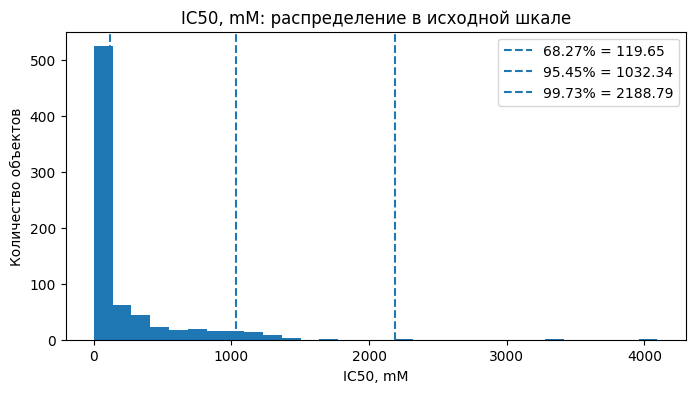

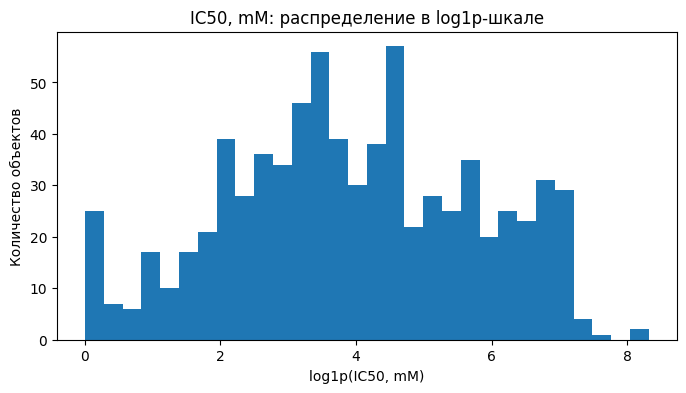

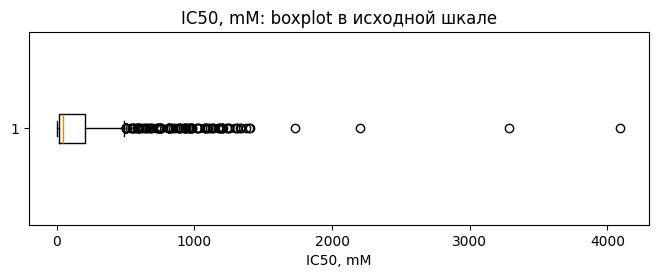

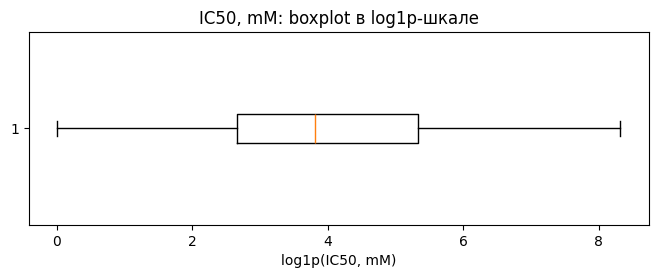


CC50, mM
count     751.000000
mean      577.426098
std       641.515163
min         0.700808
68.3%     738.035661
95.4%    1965.439708
99.7%    3919.295106
max      4538.976189
Name: CC50, mM, dtype: float64
Количество значений выше 68.27% квантиля:  238
Количество значений выше 95.45% квантиля:  33
Количество значений выше 99.73% квантиля:  3


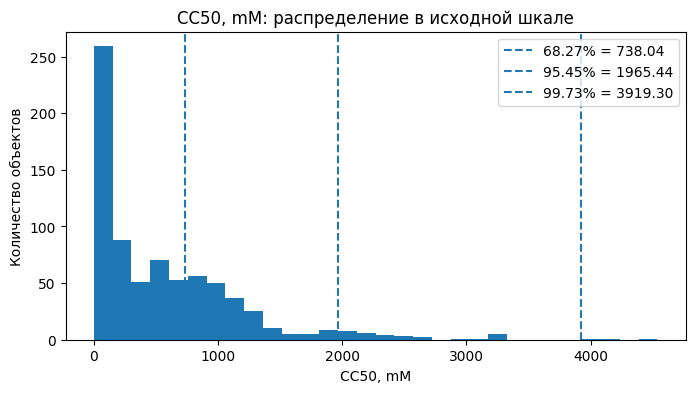

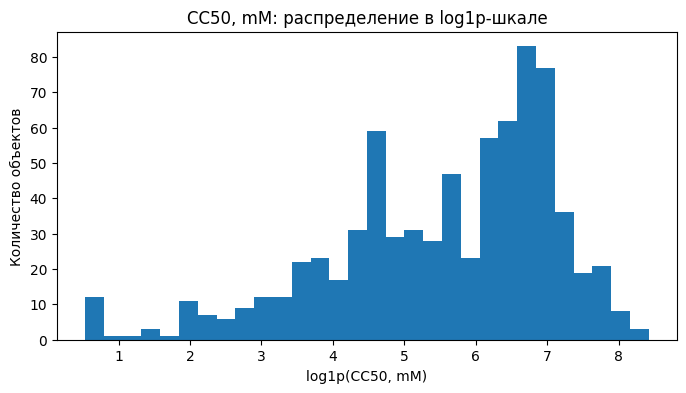

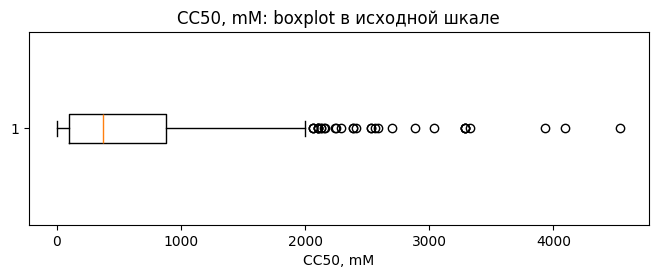

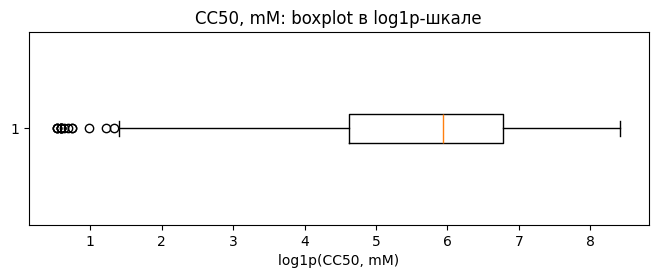


SI
count      751.000000
mean        89.153313
std        788.882198
min          0.011489
68.3%       10.529533
95.4%      159.506230
99.7%     5669.825000
max      15620.600000
Name: SI, dtype: float64
Количество значений выше 68.27% квантиля:  238
Количество значений выше 95.45% квантиля:  35
Количество значений выше 99.73% квантиля:  3


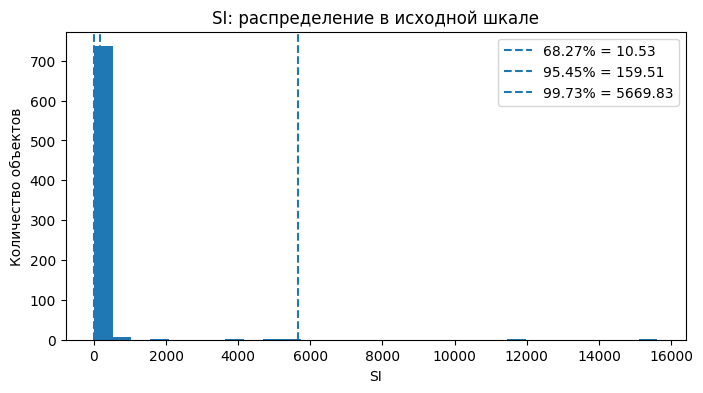

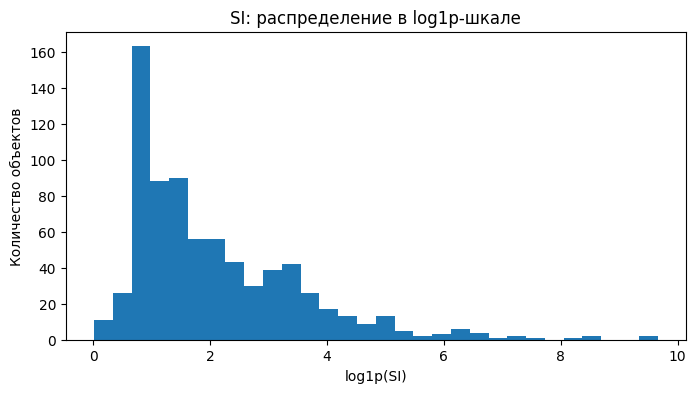

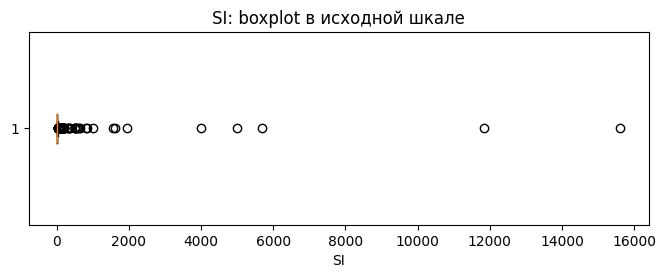

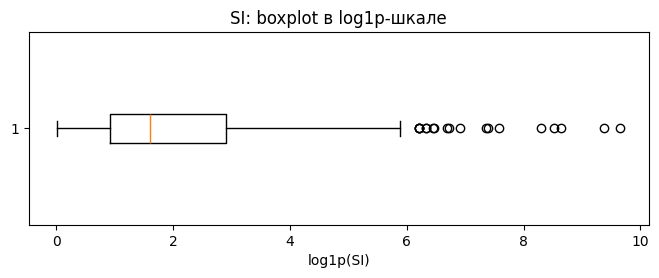

In [24]:
# Анализируем распределения целевых переменных и потенциальные верхние выбросы.
# Квантили 68.27%, 95.45% и 99.73% используются как ориентиры для оценки хвостов распределений.
quantile_levels = [0.6827, 0.9545, 0.9973]

summary_rows = []

for target in target_columns:
    values = y[target].dropna()
    
    row = {'target': target}
    row['count'] = values.shape[0]
    row['mean'] = values.mean()
    row['std'] = values.std()
    row['min'] = values.min()
    row['max'] = values.max()
    
    for q in quantile_levels:
        row[f'q{int(q * 1000) / 10:g}'] = values.quantile(q)
    
    summary_rows.append(row)

target_summary = pd.DataFrame(summary_rows)

display(target_summary)

clip_quantiles = [0.6827, 0.9545, 0.9973]

clip_rows = []

for target in target_columns:
    values = y[target].dropna()
    
    for q in clip_quantiles:
        cap = values.quantile(q)
        n_above = (values > cap).sum()
        pct_above = n_above / len(values) * 100
        
        clip_rows.append({
            'target': target,
            'cap_quantile': q,
            'cap_value': cap,
            'n_values_above_cap': n_above,
            'pct_values_above_cap': pct_above
        })

clip_table = pd.DataFrame(clip_rows)

display(clip_table)

# Визуализации
for target in target_columns:
    values = y[target].dropna()
    log_values = np.log1p(values)
    
    q6827 = values.quantile(0.6827)
    q9545 = values.quantile(0.9545)
    q9973 = values.quantile(0.9973)
    
    print('\n' + '=' * 80)
    print(target)
    print('=' * 80)
    print(values.describe(percentiles=[0.6827, 0.9545, 0.9973]))
    print(f'Количество значений выше 68.27% квантиля:  {(values > q6827).sum()}')
    print(f'Количество значений выше 95.45% квантиля:  {(values > q9545).sum()}')
    print(f'Количество значений выше 99.73% квантиля:  {(values > q9973).sum()}')
    
    # Histogram original scale
    plt.figure(figsize=(8, 4))
    plt.hist(values, bins=30)
    plt.axvline(q6827, linestyle='--', label=f'68.27% = {q6827:.2f}')
    plt.axvline(q9545, linestyle='--', label=f'95.45% = {q9545:.2f}')
    plt.axvline(q9973, linestyle='--', label=f'99.73% = {q9973:.2f}')
    plt.title(f'{target}: распределение в исходной шкале')
    plt.xlabel(target)
    plt.ylabel('Количество объектов')
    plt.legend()
    plt.show()
    
    # Histogram log1p scale
    plt.figure(figsize=(8, 4))
    plt.hist(log_values, bins=30)
    plt.title(f'{target}: распределение в log1p-шкале')
    plt.xlabel(f'log1p({target})')
    plt.ylabel('Количество объектов')
    plt.show()
    
    # Boxplot original scale
    plt.figure(figsize=(8, 2.5))
    plt.boxplot(values, vert=False)
    plt.title(f'{target}: boxplot в исходной шкале')
    plt.xlabel(target)
    plt.show()
    
    # Boxplot log1p scale
    plt.figure(figsize=(8, 2.5))
    plt.boxplot(log_values, vert=False)
    plt.title(f'{target}: boxplot в log1p-шкале')
    plt.xlabel(f'log1p({target})')
    plt.show()

In [ ]:
# Применяем клиппинг целевых переменных.
# Верхние границы выбраны экспериментально: они ограничивают влияние редких экстремальных значений
# и при этом не удаляют объекты из обучающей выборки.
# Клиппинг применяется только к тем таргетам, где он улучшал качество модели.
limits = {
    'CC50, mM': (0, 3500),
    'SI':       (0, 250),
}

y[list(limits)] = y[list(limits)].clip(
    lower={k: v[0] for k, v in limits.items()},
    upper={k: v[1] for k, v in limits.items()}
)

In [26]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

model = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

valid_pred = model.predict(X_valid)

print('Validation scores:')
for i, target in enumerate(target_columns):
    mae = mean_absolute_error(y_valid.iloc[:, i], valid_pred[:, i])
    rmse = mean_squared_error(y_valid.iloc[:, i], valid_pred[:, i]) ** 0.5
    r2 = r2_score(y_valid.iloc[:, i], valid_pred[:, i])
    print(f'{target}: MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}')

model.fit(X, y)

pred = model.predict(X_test)

submission_columns = ['IC50', 'CC50', 'SI']

submission = sample_submission.copy()
submission[submission_columns] = pred

submission.to_csv('submission.csv', index=False)
print('Saved submission.csv')

Validation scores:
IC50, mM: MAE=191.5023, RMSE=385.1059, R2=0.1958
CC50, mM: MAE=275.9275, RMSE=403.6891, R2=0.4662
SI: MAE=18.0522, RMSE=33.6513, R2=0.3754
Saved submission.csv


### Выбор финальной модели

По условию задачи были рассмотрены несколько моделей и вариантов настройки гиперпараметров, включая `RandomForestRegressor`, `ExtraTreesRegressor` и Bayesian search по сетке параметров.

Кросс-валидация использовалась как инструмент локальной оценки и сравнения моделей по метрике соревнования — среднему RMSE по трём таргетам. Однако в соревнованиях Kaggle финальное решение также проверяется по лидерборду, который отражает качество на скрытой тестовой выборке.

В ходе экспериментов более сложные модели и подобранные через BayesSearchCV параметры не дали улучшения на лидерборде относительно простой конфигурации:

`RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)`

Поэтому финальный `submission.csv` был сформирован именно этой вручную выбранной моделью.


In [ ]:
import numpy as np
import pandas as pd

from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer

from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

def mean_rmse_3_targets(y_true, y_pred):
    rmse_per_target = []

    for i in range(y_true.shape[1]):
        rmse = mean_squared_error(
            y_true.iloc[:, i] if hasattr(y_true, "iloc") else y_true[:, i],
            y_pred[:, i]
        ) ** 0.5

        rmse_per_target.append(rmse)

    return np.mean(rmse_per_target)


rmse_scorer = make_scorer(
    mean_rmse_3_targets,
    greater_is_better=False
)

cv = KFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_search_space = {
    "n_estimators": Integer(250, 900),
    "max_depth": Categorical([None, 8, 10, 12, 15, 20, 25]),
    "min_samples_split": Integer(2, 12),
    "min_samples_leaf": Integer(1, 8),
    "max_features": Categorical(["sqrt", "log2", 0.3, 0.5, 0.7, 1.0]),
    "bootstrap": Categorical([True, False]),
}

et_model = ExtraTreesRegressor(
    random_state=42,
    n_jobs=-1
)

et_search_space = {
    "n_estimators": Integer(250, 1000),
    "max_depth": Categorical([None, 8, 10, 12, 15, 20, 25]),
    "min_samples_split": Integer(2, 12),
    "min_samples_leaf": Integer(1, 8),
    "max_features": Categorical(["sqrt", "log2", 0.3, 0.5, 0.7, 1.0]),
    "bootstrap": Categorical([True, False]),
}

def run_bayes_search(
    model,
    search_space,
    X,
    y,
    cv,
    n_iter=50,
    random_state=42,
    model_name="model"
):
    search = BayesSearchCV(
        estimator=model,
        search_spaces=search_space,
        n_iter=n_iter,
        scoring=rmse_scorer,
        cv=cv,
        random_state=random_state,
        n_jobs=1,
        verbose=1,
        refit=True
    )

    search.fit(X, y)

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)
    print("Best CV MAE:", -search.best_score_)
    print("Best params:")
    print(search.best_params_)

    return search

rf_search = run_bayes_search(
    model=rf_model,
    search_space=rf_search_space,
    X=X,
    y=y,
    cv=cv,
    n_iter=50,
    random_state=42,
    model_name="RandomForestRegressor"
)

et_search = run_bayes_search(
    model=et_model,
    search_space=et_search_space,
    X=X,
    y=y,
    cv=cv,
    n_iter=50,
    random_state=42,
    model_name="ExtraTreesRegressor"
)

results = pd.DataFrame([
    {
        "model": "RandomForestRegressor",
        "best_cv_mean_rmse": -rf_search.best_score_,
        "best_params": rf_search.best_params_
    },
    {
        "model": "ExtraTreesRegressor",
        "best_cv_mean_rmse": -et_search.best_score_,
        "best_params": et_search.best_params_
    }
])

display(results.sort_values("best_cv_mean_rmse"))

best_search = rf_search if -rf_search.best_score_ <= -et_search.best_score_ else et_search
best_model_name = "RandomForestRegressor" if best_search is rf_search else "ExtraTreesRegressor"

print("Best model:", best_model_name)
print("Best CV mean RMSE:", -best_search.best_score_)
print(best_search.best_params_)

X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

best_model = best_search.best_estimator_

best_model.fit(X_train, y_train)

valid_pred = best_model.predict(X_valid)

rmse_values = []

print("Validation scores:")

for i, target in enumerate(target_columns):
    rmse = mean_squared_error(y_valid.iloc[:, i], valid_pred[:, i]) ** 0.5
    mae = mean_absolute_error(y_valid.iloc[:, i], valid_pred[:, i])
    r2 = r2_score(y_valid.iloc[:, i], valid_pred[:, i])

    rmse_values.append(rmse)

    print(f"{target}: RMSE={rmse:.4f}, MAE={mae:.4f}, R2={r2:.4f}")

print("\nCompetition metric, mean RMSE:", np.mean(rmse_values))

final_model = best_search.best_estimator_

final_model.fit(X, y)

pred = final_model.predict(X_test)

submission_columns = ["IC50", "CC50", "SI"]

submission = sample_submission.copy()
submission[submission_columns] = pred

submission.to_csv("submission_bayes_search_cv.csv", index=False)

print("Saved submission_bayes_search_cv.csv")